In [1]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

# Purana trained model aur pipeline load karein
model = joblib.load("model.pkl")
pipeline = joblib.load("pipeline.pkl")

# Jo input data save hua tha use load karein
# Isme hum check karenge ki model ne kya predict kiya tha aur asliyat kya hai
input_data = pd.read_csv("input.csv")

In [2]:
# 1. Asli keemat (Actual Values) nikaalein
y_actual = input_data["median_house_value"].copy()

# 2. Features alag karein taaki model se dubara predict karwa sakein
X_input = input_data.drop("median_house_value", axis=1)

# 3. Data ko pipeline se saaf karein (Sirf transform)
X_prepared = pipeline.transform(X_input)

# 4. Model se predictions nikaalein
predictions = model.predict(X_prepared)

C:\Users\DELL\AppData\Local\Temp\ipykernel_11312\2061490933.py:4: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(y_actual, label="Asli Keemat (Actual)", color="blue", shade=True, alpha=0.3)
C:\Users\DELL\AppData\Local\Temp\ipykernel_11312\2061490933.py:7: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(predictions, label="Model ki Keemat (Predicted)", color="red", shade=True, alpha=0.3)


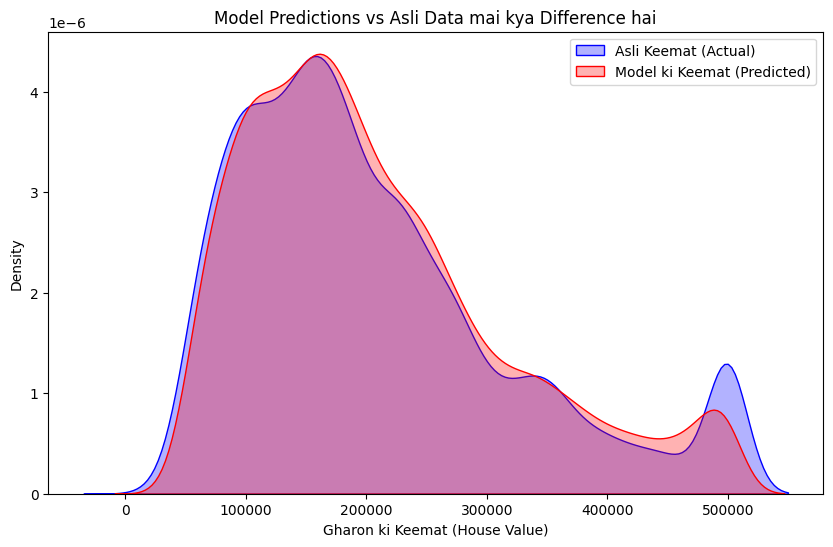

In [3]:
plt.figure(figsize=(10, 6))

# Actual values ka distribution (Blue rang mai)
sns.kdeplot(y_actual, label="Asli Keemat (Actual)", color="blue", shade=True, alpha=0.3)

# Model ki predicted values ka distribution (Red rang mai)
sns.kdeplot(predictions, label="Model ki Keemat (Predicted)", color="red", shade=True, alpha=0.3)

plt.title("Model Predictions vs Asli Data mai kya Difference hai")
plt.xlabel("Gharon ki Keemat (House Value)")
plt.ylabel("Density")
plt.legend()
plt.show()